# EUROPEAN CALL OPTION WITH MONTE CARLO

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import scipy

In [2]:

#array for number of samples
N = np.array([100,500,1000,5000,10000,50000,100000,500000,1000000])

def MC(N):
    #standard normal distribution with size = sample length/2
    Z = np.random.randn(int(N/2))
    #antithetic variable technique to reduce variance and fasten convergence
    Z = np.concatenate([Z, -Z])

    #GBM stock price after T= 1. Take SO = 1.
    T = 1.
    S0 = 1.
    r = 0.03
    sigma = 0.20
    S_T = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)

    #payoff
    K = 1.
    C_T = np.maximum(S_T - K, 0)

    #expectation value/valuation of the call at t=0
    return np.exp(-r*T) * C_T.mean()



In [3]:
european_call_payoffs = np.zeros(len(N))

for i in range(0, len(N)):
    european_call_payoffs[i] = MC(N[i])

In [4]:
def euro_call(x, tau, K, r, sig):
   
    d2 = (x + (r - 0.5*sig**2)*tau) / (sig*np.sqrt(tau))
    d1 = d2 + sig*np.sqrt(tau)
    return K*np.exp(x)*scipy.stats.norm.cdf(d1) - K*np.exp(-r*tau)*scipy.stats.norm.cdf(d2)

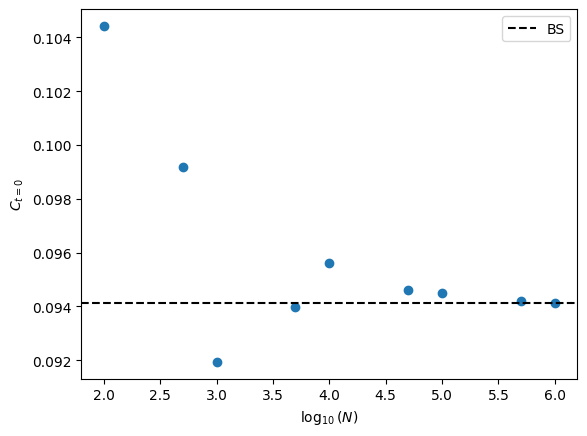

In [5]:
plt.scatter(np.log10(N), european_call_payoffs)
plt.axhline(y = euro_call(0.,1.,1.,0.03,0.20), c='black', linestyle='dashed', label ='BS')
plt.xlabel(r'$\log_{10}(N)$')
plt.ylabel(r'$C_{t=0}$')
plt.legend()
plt.show()

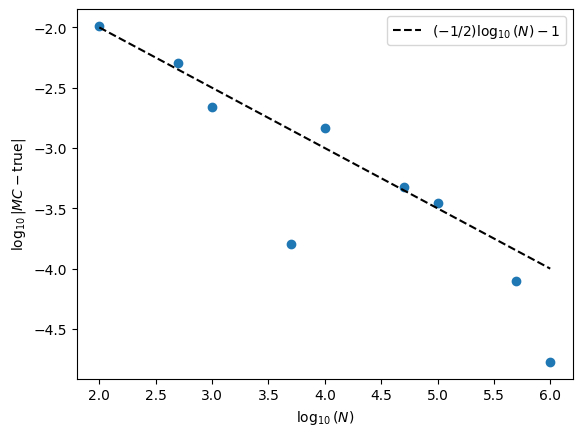

In [6]:
plt.scatter(np.log10(N), np.log10(np.abs(european_call_payoffs - euro_call(0.,1.,1.,0.03,0.20))))
plt.plot(np.log10(N), (-1/2)*np.log10(N) - 1, c='black', linestyle='dashed', label =r'$(-1/2)\log_{10}(N)-1$')
plt.xlabel(r'$\log_{10}(N)$')
plt.ylabel(r'$\log_{10}|{MC-\text{true}}|$')
plt.legend()
plt.show()